In [61]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

from PlanningDynamics import utils, graph
from PlanningDynamics.dataClass import nwbWrapper
from pingouin import pairwise_tukey, linear_regression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

Processing london: 100%|██████████| 7/7 [00:18<00:00,  2.61s/it]

ANOVA results: Subject B
|    |   A |   B |   mean(A) |   mean(B) |     diff |    se |        T |     p-tukey |    hedges |
|---:|----:|----:|----------:|----------:|---------:|------:|---------:|------------:|----------:|
|  0 |   0 |   1 |   1.32023 |   51.7473 | -50.4271 | 2.544 | -19.822  | 1.23235e-14 |  -8.11123 |
|  1 |   0 |   3 |   1.32023 |   98.3169 | -96.9967 | 2.544 | -38.1276 | 0           | -43.7372  |
|  2 |   1 |   3 |  51.7473  |   98.3169 | -46.5696 | 2.544 | -18.3057 | 6.36158e-14 |  -7.07599 |
ANOVA results: Subject L
|    |   A |   B |   mean(A) |   mean(B) |     diff |      se |        T |     p-tukey |     hedges |
|---:|----:|----:|----------:|----------:|---------:|--------:|---------:|------------:|-----------:|
|  0 |   0 |   1 |   2.25446 |   73.9101 | -71.6556 | 1.62211 | -44.1742 | 0           |  -18.3113  |
|  1 |   0 |   3 |   2.25446 |   99.4805 | -97.2261 | 1.62211 | -59.9379 | 0           | -106.895   |
|  2 |   1 |   3 |  73.9101  |   99.4805 | -25.

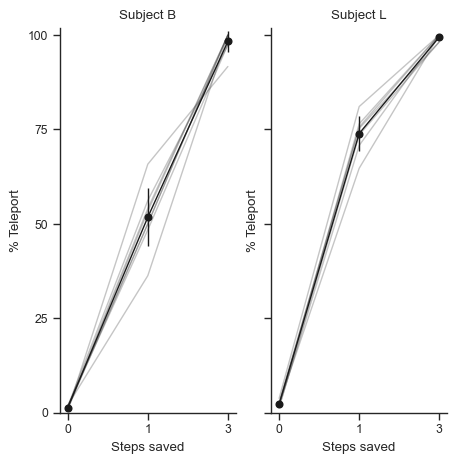

In [58]:
def fig1C():
    fnames = utils.get_filenames()
    
    g_space = graph.grid_graph(4, 4)
    g_tele = graph.grid_graph(4, 4, tele=[0, 15])
    def tele_steps_saved(start, stop):
        space_dist = nx.shortest_path_length(g_space, start, stop)
        graph_dist = nx.shortest_path_length(g_tele, start, stop)
        return np.abs(space_dist - graph_dist)
    
    def run(fname):
        data = nwbWrapper(fname, region="OFC", to_load="bhv")
        trial_df = graph.append_use_tele(data.trial_df.query("trialerror < 2").copy())
        trial_df["tele_steps_saved"] = trial_df.apply(lambda row: tele_steps_saved(int(row.loc["start"]),
                                                                                             int(row.loc["target"])), axis=1)
        return trial_df.groupby("tele_steps_saved")["use_tele"].mean().values * 100
    
    use_tele = utils.iterate_subjects(fnames, run)
    for key in use_tele:
        use_tele[key] = np.array(use_tele[key])
    
    sns.set(style="ticks", context="paper")
    fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(5, 5))
    
    for j, sbj in enumerate(use_tele):    
    
        x = np.arange(3)
        for i in range(len(use_tele[sbj])):
            ax[j].plot(x, use_tele[sbj][i], color="k", alpha=0.25, lw=1)
        ax[j].errorbar(x, use_tele[sbj].mean(axis=0), yerr= use_tele[sbj].std(axis=0), color="k", lw=1, marker="o")
        
        ax[j].set_xticks(x, [0, 1, 3])
        ax[j].set_xlabel("Steps saved")  
        ax[j].set_title("Subject {}".format(sbj[0].upper()))
        ax[j].set_ylabel("% Teleport")
        ax[j].set_yticks([0, 25, 50, 75, 100])
        ax[j].set_ylim([0, 102])
        
        
        anova_df = pd.DataFrame({"p_tele": use_tele[sbj].reshape(-1),
                                 
                                 "step_saved": np.tile([0, 1, 3], len(use_tele[sbj]))})
        tukey = pairwise_tukey(anova_df, dv="p_tele", between="step_saved")
        print("ANOVA results: Subject %s" % sbj[0].capitalize())
        print(tukey.to_markdown())
    sns.despine() 

fig1C()        

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

Processing london: 100%|██████████| 7/7 [00:03<00:00,  2.09it/s]

Regression results for <built-in method capitalize of str object at 0x7d6fd7ea1530>:
|    | names     |        coef |         se |         T |        pval |          r2 |     adj_r2 |    CI[2.5%] |   CI[97.5%] |
|---:|:----------|------------:|-----------:|----------:|------------:|------------:|-----------:|------------:|------------:|
|  0 | Intercept | 0.906951    | 0.0102731  | 88.2841   | 3.64966e-51 | 0.000300108 | -0.0224203 |  0.886247   |  0.927655   |
|  1 | x1        | 0.000373364 | 0.00324864 |  0.114929 | 0.909024    | 0.000300108 | -0.0224203 | -0.00617384 |  0.00692056 |
Regression results for <built-in method capitalize of str object at 0x7d6fd7e5dcf0>:
|    | names     |       coef |         se |          T |        pval |         r2 |      adj_r2 |    CI[2.5%] |   CI[97.5%] |
|---:|:----------|-----------:|-----------:|-----------:|------------:|-----------:|------------:|------------:|------------:|
|  0 | Intercept | 0.914799   | 0.00742093 | 123.273    | 7.25556e-6

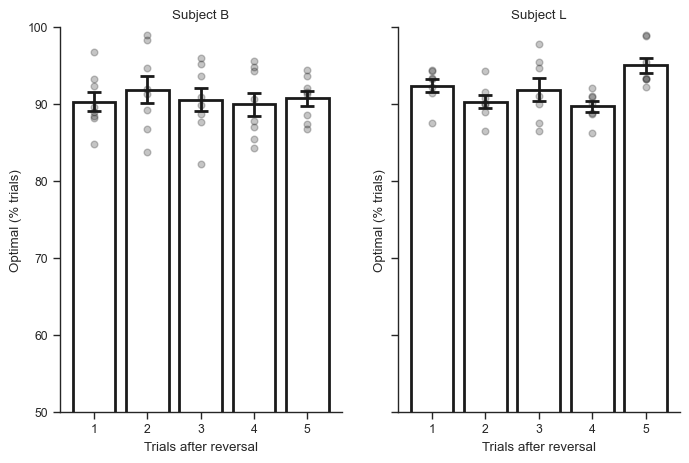

In [56]:
def fig1D(): 
    
    def get_reversal_accuracy(fname):
        data = nwbWrapper(fname, region="OFC", to_load="trial_df")
        #g_tele = graph.grid_graph(4, 4, tele=[0, 15])
        data.trial_df["optimal_steps"] = data.trial_df.apply(lambda row:
            graph.distance(int(row.loc["start"]), int(row.loc["target"])),
            axis=1)
        data.trial_df["if_missteps"] = (data.trial_df["nsteps"] - data.trial_df["optimal_steps"]) > 0
        return 1 - data.trial_df[data.trial_df.trialerror < 2].groupby("blocktrialnumber")["if_missteps"].mean().loc[3:10].values

    fnames = utils.get_filenames()
    reversal_accuracy = utils.iterate_subjects(fnames, get_reversal_accuracy)

    sns.set(style="ticks", context="paper")
    fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(8, 5))
    
    for i, sbj in enumerate(reversal_accuracy):
        reversal_accuracy[sbj] = np.array(reversal_accuracy[sbj])
        n_sessions = reversal_accuracy[sbj].shape[0]
        x = np.arange(1, 6)
        to_plot = reversal_accuracy[sbj][:, :5]
        
        ax[i].plot(x, to_plot.T, c="k", alpha=0.25, marker="o", linestyle="None")
        ax[i].bar(x, to_plot.mean(axis=0), yerr=to_plot.std(axis=0)/np.sqrt(n_sessions), 
                edgecolor="k", ecolor="k", facecolor="None", capsize=5, linewidth=2, error_kw={"elinewidth":2, "capthick":2})
        ax[i].set_ylim([0.5, 1])
        ax[i].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1], [50, 60, 70, 80, 90, 100])
        ax[i].set_ylabel("Optimal (% trials)")
        ax[i].set_xlabel("Trials after reversal")
        ax[i].set_title("Subject {}".format(sbj[0].upper()))
        
        if sbj == "bart":    
            trial_after_reversal_npx = np.meshgrid(np.arange(8), np.arange(2))[0].reshape(-1, 1).flatten()
            bart_data_npx = reversal_accuracy[sbj][:2, :8].reshape(-1, 1).flatten()
            
            
            trial_after_reversal_plx = np.meshgrid(np.arange(5), np.arange(6))[0].reshape(-1, 1).flatten()
            bart_data_plx = reversal_accuracy[sbj][2:, :5].reshape(-1, 1).flatten()
            
            trial_after_reversal = np.concatenate([trial_after_reversal_npx, trial_after_reversal_plx])
            sbj_data = np.concatenate([bart_data_npx, bart_data_plx])
        else:
            trial_after_reversal = np.meshgrid(np.arange(8), np.arange(n_sessions))[0].reshape(-1, 1).flatten()
            sbj_data = reversal_accuracy[sbj].reshape(-1, 1).flatten()

        df = pd.DataFrame({"p_tele":sbj_data, "trial_after_reversal":trial_after_reversal})
        res = linear_regression(X=trial_after_reversal, y=sbj_data, add_intercept=True)

        print("Regression results for %s:" % sbj[0].capitalize)
        print(res.to_markdown())
            
        
    ax[0].set_xticks([1, 2, 3, 4, 5])
    sns.despine()
    #return fig, ax, reversal_accuracy

fig1D()

In [72]:
def run(fname):
    data = nwbWrapper(fname, "OFC", to_load="all")
    data.choice_df["start_distance"] = data.choice_df.apply(lambda row: graph.distance(row.start, row.target), axis=1)
    trials = data.choice_df.trial.unique()
    rts = []
    for trial in trials:
        evs, ets = data.trial_spikes[trial].evs, data.trial_spikes[trial].ets

        rts.append(utils.get_rts(dict(times=ets, numbers=evs)))
    rts = np.hstack(rts)
    data.choice_df["rt"] = rts
    df = data.choice_df.loc[:, ["start_distance", "rt", "graph_distance", "step", "nsteps", "trial"]]
    return df

res = run(fnames["london"][0])

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 650.36it/s]


loading choice data:


100%|██████████| 2735/2735 [00:02<00:00, 1338.82it/s]


loading fixations:
computing choice fixation times


In [74]:
p25 = lambda x: np.abs(np.percentile(x, 25) - np.median(x))
p75 = lambda x: np.abs(np.percentile(x, 75) - np.median(x))
to_plot = res.query("(step ==  1)").groupby("start_distance").rt.agg(["mean", "sem", "median", p25, p75])

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 661.88it/s]


loading choice data:


100%|██████████| 1529/1529 [00:01<00:00, 1307.44it/s]


...

100%|██████████| 943/943 [00:01<00:00, 645.68it/s]


loading choice data:


100%|██████████| 2735/2735 [00:02<00:00, 1341.01it/s]


loading fixations:
computing choice fixation times


Processing london: 100%|██████████| 7/7 [00:53<00:00,  7.59s/it]


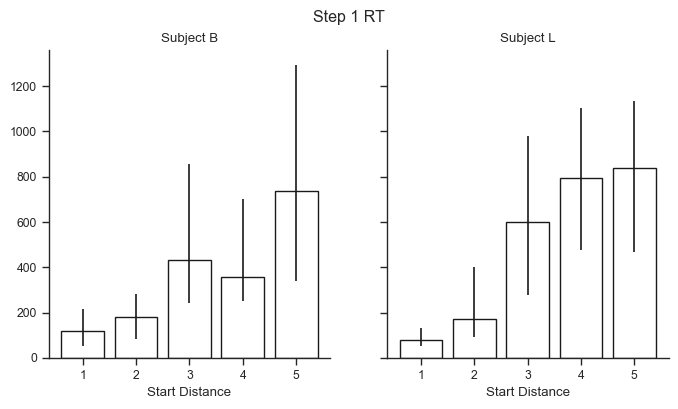

: 

In [77]:
def suppFig1():
    fnames = utils.get_filenames()
    
    def run(fname):
        data = nwbWrapper(fname, "OFC", to_load="all")
        data.choice_df["start_distance"] = data.choice_df.apply(lambda row: graph.distance(row.start, row.target), axis=1)
        trials = data.choice_df.trial.unique()
        rts = []
        for trial in trials:
            evs, ets = data.trial_spikes[trial].evs, data.trial_spikes[trial].ets

            rts.append(utils.get_rts(dict(times=ets, numbers=evs)))
        rts = np.hstack(rts)
        data.choice_df["rt"] = rts
        df = data.choice_df.loc[:, ["start_distance", "rt", "graph_distance", "step", "nsteps", "trial"]]
        return df
    
    rts_all = utils.iterate_subjects(fnames, run)
    for key in rts_all:
        rts_all[key] = pd.concat(rts_all[key], axis=0)
        
    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
    for i, sbj in enumerate(rts_all):
        p25 = lambda x: np.abs(np.percentile(x, 25) - np.median(x))
        p75 = lambda x: np.abs(np.percentile(x, 75) - np.median(x))
        to_plot = rts_all[sbj].query("(step ==  1)").groupby("start_distance").rt.agg(["mean", "sem", "median", p25, p75])
        ax[i].bar(np.arange(0, 5), to_plot["median"], yerr=np.array([to_plot["<lambda_0>"], 
                                                                     to_plot["<lambda_1>"]]), alpha=1, color="k", facecolor="None", edgecolor="k", linewidth=1)
        ax[i].set_xticks([0, 1, 2, 3, 4], ["1", "2", "3", "4", "5"])
        ax[i].set_title("Subject {}".format(sbj[0].capitalize()))
        ax[i].set_xlabel("Start Distance")
    ax[0].set_ylabbel("RT (s)")
    fig.suptitle("Step 1 RT")
    sns.despine()
    
suppFig1()